# Cross-Domain Recommendation with EMCDR
*Cold-start recommendation by transferring user taste across Amazon verticals.*

Walkthrough order: **data & EDA → baselines → our solution (EMCDR) → improvements & honest boundary.**

## Setup


In [1]:
# ── Setup: imports, brand theme, paths, palette ────────────────────────────
import os, json, gc, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch, FancyBboxPatch, FancyArrowPatch
import seaborn as sns
warnings.filterwarnings('ignore')

# ---- brand palette ---------------------------------------------------------
BG        = '#F7F7FC'   # page background (soft lavender)
INK       = '#2B2D42'   # titles / primary text
INK_SOFT  = '#6E6B85'   # axis labels / secondary text
GRIDC     = '#E7E4F1'   # hairline grid
SPINEC    = '#CFCADB'   # baseline spine

PURPLE    = '#6C4DF6'   # hero / primary
PURPLE_DK = '#4A2FD0'
PURPLE_LT = '#B6A9F7'
ORANGE    = '#F7A81B'   # highlight accent
CORAL     = '#F65C6C'   # negative
TEAL      = '#16C2C2'
GREEN     = '#23B26D'
NEUTRAL   = '#CBC6DD'   # muted neutral
NAVY      = PURPLE      # back-compat alias used by later cells

# 5 distinguishable, on-brand hues — one per vertical
VERT_PAL  = ['#6C4DF6', '#9B5DE5', '#F15BB5', '#F7A81B', '#16C2C2']
# white -> purple sequential map for heatmaps
PURPLES   = LinearSegmentedColormap.from_list(
    'brand_purples', ['#FFFFFF', '#DCD3FB', '#9B86F2', PURPLE, PURPLE_DK])

# ---- matplotlib theme ------------------------------------------------------
plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'font.family': 'DejaVu Sans', 'font.size': 12,
    'text.color': INK, 'axes.labelcolor': INK_SOFT,
    'xtick.color': INK_SOFT, 'ytick.color': INK_SOFT,
    'axes.titlesize': 15, 'axes.titleweight': 'bold',
    'axes.labelsize': 11.5, 'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.spines.left': False, 'axes.spines.bottom': True,
    'axes.edgecolor': SPINEC, 'axes.linewidth': 1.1, 'axes.grid': False,
    'figure.facecolor': BG, 'axes.facecolor': BG, 'savefig.facecolor': BG,
    'xtick.major.size': 0, 'ytick.major.size': 0,
})

# ---- reusable style helpers ------------------------------------------------
def style_bar_axis(ax, axis='x'):
    """Strip the frame down to a single baseline spine; tint the panel."""
    ax.set_facecolor(BG)
    for s in ax.spines.values(): s.set_visible(False)
    base = 'bottom' if axis == 'x' else 'left'
    ax.spines[base].set_visible(True)
    ax.spines[base].set_color(SPINEC); ax.spines[base].set_linewidth(1.1)
    ax.tick_params(length=0); ax.grid(False)

def style_line_axis(ax):
    ax.set_facecolor(BG)
    for s in ax.spines.values(): s.set_visible(False)
    ax.spines['bottom'].set_visible(True); ax.spines['bottom'].set_color(SPINEC)
    ax.tick_params(length=0)
    ax.grid(True, color=GRIDC, lw=0.9); ax.set_axisbelow(True)

def soft_grid(ax, axis='y'):
    ax.grid(axis=axis, color=GRIDC, lw=0.9); ax.set_axisbelow(True)

def ctitle(ax, text, pad=14, size=13.5):
    ax.set_title(text, loc='center', color=INK, fontweight='bold', pad=pad, fontsize=size)

def brand_legend(ax, **kw):
    kw.setdefault('frameon', False)
    leg = ax.legend(**kw)
    for t in leg.get_texts(): t.set_color(INK)
    return leg

# ---- paths -----------------------------------------------------------------
ROOT = Path(os.environ.get('AMAZON_CR_ROOT', '/Users/orimood/Desktop/homework/Amazon_CR'))
if not ROOT.exists():                      # portable fallback (e.g. run from ./notebooks)
    _here = Path.cwd(); ROOT = _here.parent if _here.name == 'notebooks' else _here
PROC  = ROOT / 'data' / 'processed'
RES   = ROOT / 'results'
CACHE = ROOT / 'notebooks' / '_cache'

VERTICALS = ['Books', 'Movies_and_TV', 'CDs_and_Vinyl', 'Video_Games', 'Toys_and_Games']
LBL = {'Books':'Books', 'Movies_and_TV':'Movies & TV', 'CDs_and_Vinyl':'CDs & Vinyl',
       'Video_Games':'Video Games', 'Toys_and_Games':'Toys & Games',
       'Video_Games_3core':'Video Games (3-core)'}
SHORT = {'Books':'Books', 'Movies_and_TV':'Movies', 'CDs_and_Vinyl':'CDs',
         'Video_Games':'V.Games', 'Toys_and_Games':'Toys', 'Video_Games_3core':'V.Games³ᶜ'}

# per-vertical categorical colors (consistent across every EDA figure)
VCOLORS = {v: VERT_PAL[i] for i, v in enumerate(VERTICALS)}

# model colors: baselines muted, EMCDR the single saturated accent
MODEL_COLORS = {'emcdr':PURPLE, 'baseline_target_mf':ORANGE,
                'baseline_feature_transfer':TEAL, 'baseline_mostpop':PURPLE_LT,
                'baseline_random':NEUTRAL}
MODEL_LBL = {'emcdr':'EMCDR', 'baseline_target_mf':'target-MF',
             'baseline_feature_transfer':'content-transfer', 'baseline_mostpop':'MostPop',
             'baseline_random':'Random'}
HEADLINE = 'Recall@10'
print('setup ready ·', plt.rcParams['figure.dpi'], 'dpi ·', len(VERTICALS),
      'verticals · root', ROOT.name)

setup ready · 130.0 dpi · 5 verticals · root Amazon_CR


In [2]:
# ── Helpers: results access + plotting (keep the figure cells DRY) ─────────
def kfmt(n):
    n = float(n)
    if n >= 1e6: return f'{n/1e6:.1f}M'
    if n >= 1e3: return f'{n/1e3:.0f}k'
    return f'{n:.0f}'

def finish(fig):
    fig.tight_layout(); plt.show()

def bar_annotated(ax, bars, vals, fmt='{:.3f}', fs=9, dy=None, color=INK):
    if dy is None:
        dy = 0.012 * max([b.get_height() for b in bars] + [1e-9])
    for b, v in zip(bars, vals):
        if np.isnan(v): continue
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+dy, fmt.format(v),
                ha='center', va='bottom', fontsize=fs, color=color, fontweight='bold')

# results JSON ----------------------------------------------------------------
_GRID = {}
def load_grid(tag):
    if tag not in _GRID:
        _GRID[tag] = json.load(open(RES / f'GRID__{tag}.json'))['results']
    return _GRID[tag]

def entry(tag, src, tgt, ablation='full'):
    for r in load_grid(tag):
        if r['src'] == src and r['tgt'] == tgt and r['ablation'] == ablation:
            return r
    raise KeyError((tag, src, tgt, ablation))

def mval(e, model, metric=HEADLINE):
    m = e['metrics'].get(model)
    return float(m[metric]['mean']) if m else float('nan')

BASELINES = ['baseline_target_mf', 'baseline_feature_transfer',
             'baseline_mostpop', 'baseline_random']
ALLMODELS = ['emcdr'] + BASELINES

def winner_of(e, metric=HEADLINE):
    c = {m: mval(e, m, metric) for m in ALLMODELS if m in e['metrics']}
    return max(c, key=c.get)

def best_baseline(e, metric=HEADLINE):
    c = {m: mval(e, m, metric) for m in BASELINES if m in e['metrics']}
    return max(c, key=c.get)

def plabel(s, t):
    return f'{SHORT[s]}→{SHORT[t]}'

def arr_lbl(s, t):
    return f'{SHORT[s]} → {LBL[t]}'

def entries_for(tag, pairs, ablation='full'):
    return [entry(tag, s, t, ablation) for s, t in pairs]

def grouped_models(ax, pairs, ents, models, ylabel, title, annotate='emcdr', metric=HEADLINE):
    x = np.arange(len(pairs)); n = len(models); w = 0.82/n
    for k, m in enumerate(models):
        vals = [mval(e, m, metric) for e in ents]
        bars = ax.bar(x + (k-(n-1)/2)*w, vals, w, label=MODEL_LBL[m],
                      color=MODEL_COLORS[m], edgecolor=BG, linewidth=0.8, zorder=3)
        if m == annotate:
            bar_annotated(ax, bars, vals, fmt='{:.2f}', fs=8.5)
    ax.set_xticks(x); ax.set_xticklabels([plabel(s, t) for s, t in pairs], rotation=20, ha='right')
    ax.set_ylabel(ylabel); ctitle(ax, title, size=14)
    style_bar_axis(ax, 'x'); soft_grid(ax, 'y')
    brand_legend(ax, ncol=len(models), fontsize=9.5, loc='upper center',
                 bbox_to_anchor=(0.5, 1.0), handletextpad=0.5, columnspacing=1.2)

# the 8 study pairs, ordered by shared-user overlap (descending)
PAIRS_FULL = [('Books','Movies_and_TV'), ('Books','Toys_and_Games'),
              ('Movies_and_TV','Toys_and_Games'), ('Movies_and_TV','CDs_and_Vinyl'),
              ('Books','CDs_and_Vinyl'), ('Movies_and_TV','Video_Games'),
              ('Toys_and_Games','Video_Games'), ('Books','Video_Games')]
# "deployed" config: 5 rich pairs from the regularized-linear map, 3 Video-Games pairs from 3-core
DEPLOYED = [('Books','Movies_and_TV','improve_lin'), ('Books','Toys_and_Games','improve_lin'),
            ('Movies_and_TV','Toys_and_Games','improve_lin'), ('Movies_and_TV','CDs_and_Vinyl','improve_lin'),
            ('Books','CDs_and_Vinyl','improve_lin'), ('Movies_and_TV','Video_Games_3core','b1_3core'),
            ('Toys_and_Games','Video_Games_3core','b1_3core'), ('Books','Video_Games_3core','b1_3core')]
print('helpers ready · tags cached:', list(_GRID.keys()) or 'none yet')

helpers ready · tags cached: none yet


In [3]:
# ── Dataset stats (canonical, post-pipeline) ───────────────────────────────
DESC = json.load(open(PROC / 'dataset_description.json'))
def vstat(v):      return DESC['verticals'][v]
def pstat(s, t):   return DESC['pairs'][f'{s}__{t}']
print('loaded dataset_description ·', len(DESC['verticals']), 'verticals ·',
      len(DESC['pairs']), 'pairs · category vocab', DESC['category_vocab_size'])

loaded dataset_description · 5 verticals · 8 pairs · category vocab 3092


## 2 · Data & EDA
Five Amazon verticals, eight cross-domain (source → target) pairs. Stats come from the
post-pipeline snapshot; heavy distributions are computed once from the processed interactions
and cached so a re-run is instant.

In [4]:
# ── Precompute + cache heavy EDA aggregates (first run ~60s, re-runs seconds) ──
CACHE.mkdir(parents=True, exist_ok=True)

def _build_heavy():
    yearly, di, du = [], [], []
    for v in VERTICALS:
        df = pd.read_parquet(PROC / v / 'interactions.parquet',
                             columns=['user_idx', 'item_idx', 'label', 'timestamp'])
        df = df[df['label'] == 1]                                   # positive interactions
        yr = pd.to_datetime(df['timestamp'], unit='ms', errors='coerce').dt.year
        for y, c in yr.dropna().astype(int).value_counts().sort_index().items():
            yearly.append((v, int(y), int(c)))
        di.append(pd.DataFrame({'vertical': v, 'pop': df['item_idx'].value_counts().values}))
        du.append(pd.DataFrame({'vertical': v, 'deg': df['user_idx'].value_counts().values}))
        del df; gc.collect()
    return (pd.DataFrame(yearly, columns=['vertical', 'year', 'count']),
            pd.concat(di, ignore_index=True), pd.concat(du, ignore_index=True))

_need = [n for n in ('yearly', 'deg_item', 'deg_user') if not (CACHE / f'{n}.parquet').exists()]
if _need:
    print('building cache:', _need, '...')
    y, di, du = _build_heavy()
    y.to_parquet(CACHE / 'yearly.parquet')
    di.to_parquet(CACHE / 'deg_item.parquet')
    du.to_parquet(CACHE / 'deg_user.parquet')

yearly   = pd.read_parquet(CACHE / 'yearly.parquet')
deg_item = pd.read_parquet(CACHE / 'deg_item.parquet')
deg_user = pd.read_parquet(CACHE / 'deg_user.parquet')
print('cache ready · yearly', yearly.shape, '· deg_item', deg_item.shape,
      '· deg_user', deg_user.shape)

cache ready · yearly (131, 3) · deg_item (872858, 2) · deg_user (1847781, 2)


In [5]:
# ── Verified EDA constants (from notebooks/eda.ipynb + figures/make_figures.py) ──
# 1..5 star counts over real reviews (positives carry only 4-5 stars post-filter, so the
# full star profile is sourced from the verified pre-sampling recount).
RATING_COUNTS = {
    'Books':          [1299569, 1068843, 2032688, 4582684, 20155541],
    'Movies_and_TV':  [1395560,  759530, 1248470, 2580157, 11174802],
    'CDs_and_Vinyl':  [ 185013,  138843,  280338,  657119,  3510758],
    'Video_Games':    [ 579987,  246344,  335256,  608231,  2785682],
    'Toys_and_Games': [1608590,  758252, 1090727, 1775628, 10819243]}
RATING_COLORS = ['#b2182b', '#ef8a62', '#f7d486', '#a6d96a', '#1a9850']  # 1★→5★

POP_FIELDS = ['title', 'description', 'features', 'categories', 'main_category', 'store', 'details', 'price']
POP = {'Books':          [100.0, 41.4, 88.3, 88.1, 99.8, 96.1, 93.3, 86.1],
       'Movies_and_TV':  [ 58.0, 46.5,  5.0, 57.9, 95.1, 52.5, 98.6, 35.3],
       'CDs_and_Vinyl':  [100.0, 64.9,  0.2,100.0, 99.9, 99.9, 96.6, 78.7],
       'Video_Games':    [100.0, 62.3, 71.2, 90.8, 92.0, 96.8, 97.5, 45.2],
       'Toys_and_Games': [100.0, 65.7, 80.1, 90.0, 97.5, 99.4, 97.7, 48.1]}
# avg item-text richness per pair (for the overlap-vs-richness tradeoff)
PAIR_RICH = {('Books','Movies_and_TV'):0.653, ('Books','Toys_and_Games'):0.809,
             ('Movies_and_TV','Toys_and_Games'):0.697, ('Movies_and_TV','CDs_and_Vinyl'):0.712,
             ('Books','CDs_and_Vinyl'):0.824, ('Movies_and_TV','Video_Games'):0.693,
             ('Toys_and_Games','Video_Games'):0.848, ('Books','Video_Games'):0.804}
print('constants ready')

constants ready


### 2.1 · Catalog scale & sparsity

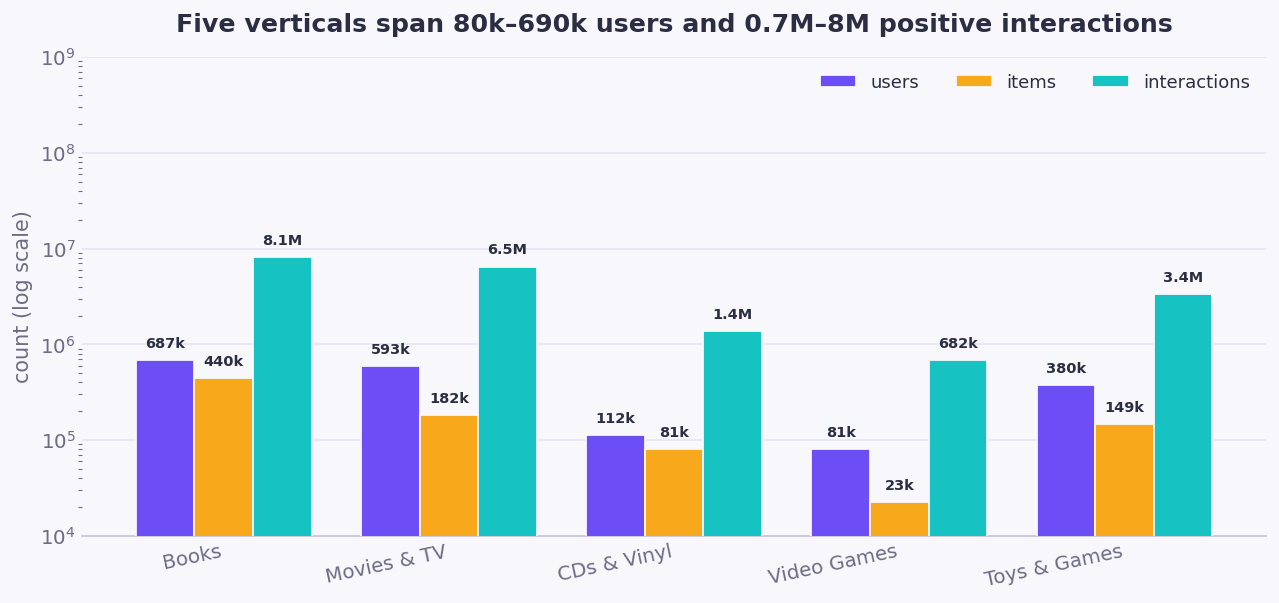

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.8))
metrics = [('users_5core', 'users', PURPLE),
           ('items_5core', 'items', ORANGE),
           ('interactions_5core', 'interactions', TEAL)]
x = np.arange(len(VERTICALS)); w = 0.26
for k, (key, name, col) in enumerate(metrics):
    vals = [vstat(v)['select'][key] for v in VERTICALS]
    bars = ax.bar(x + (k-1)*w, vals, w, label=name, color=col, edgecolor=BG, zorder=3)
    for b, val in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, val*1.25, kfmt(val), ha='center', va='bottom',
                fontsize=8, color=INK, fontweight='bold')
ax.set_yscale('log'); ax.set_ylim(1e4, 1e9)
ax.set_xticks(x); ax.set_xticklabels([LBL[v] for v in VERTICALS], rotation=12, ha='right')
ax.set_ylabel('count (log scale)')
ctitle(ax, 'Five verticals span 80k–690k users and 0.7M–8M positive interactions', size=14)
style_bar_axis(ax, 'x'); soft_grid(ax, 'y')
brand_legend(ax, ncol=3, loc='upper right')
finish(fig)

### 2.2 · 5-core retention

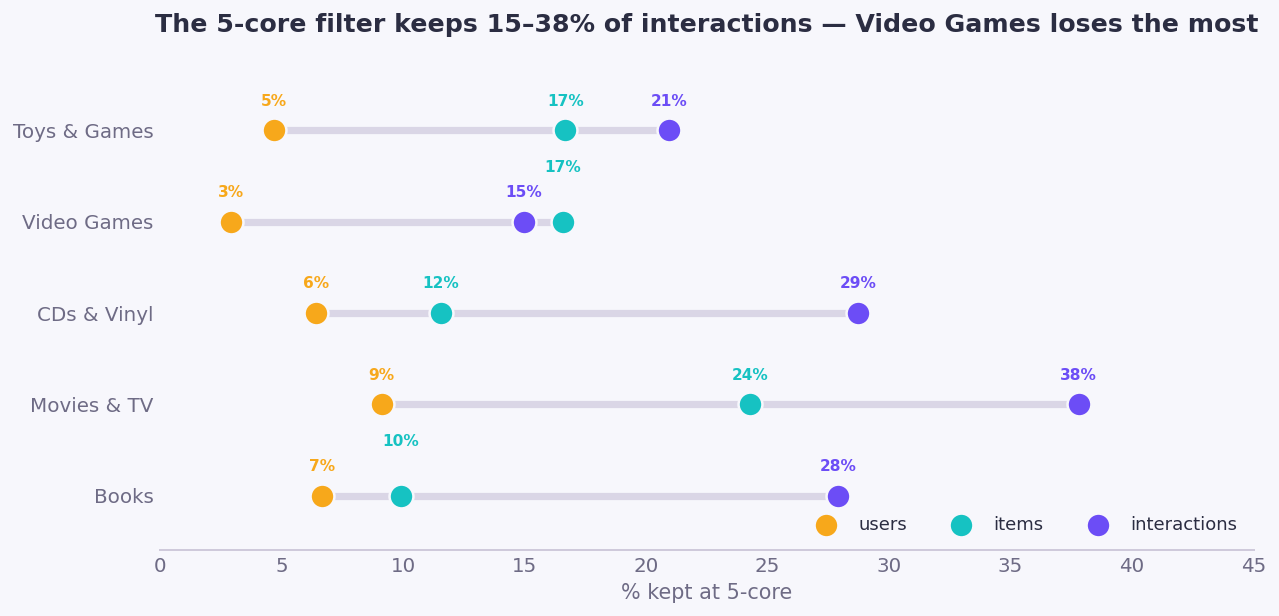

In [7]:
def _ret(v):
    s = vstat(v)['select']
    return [s['retention_pct_vs_0core'],
            100*s['users_5core']/s['users_0core'],
            100*s['items_5core']/s['items_0core']]
names = ['interactions', 'users', 'items']; dotc = [PURPLE, ORANGE, TEAL]
R = {v: _ret(v) for v in VERTICALS}
fig, ax = plt.subplots(figsize=(10, 4.9))
y = np.arange(len(VERTICALS))
for i, v in enumerate(VERTICALS):
    vals = R[v]
    ax.plot([min(vals), max(vals)], [i, i], color='#DAD6E6', lw=4, zorder=1, solid_capstyle='round')
    placed = []
    for k in sorted(range(3), key=lambda j: vals[j]):           # lay out low -> high
        ax.scatter(vals[k], i, s=175, color=dotc[k], zorder=3, edgecolor=BG, linewidth=1.4,
                   label=names[k] if i == 0 else None)
        near = sum(1 for j in placed if abs(vals[k]-vals[j]) < 3.5)   # crowded? stack higher
        ax.annotate(f'{vals[k]:.0f}%', (vals[k], i), xytext=(0, 12+14*near), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8.5, color=dotc[k], fontweight='bold')
        placed.append(k)
ax.set_yticks(y); ax.set_yticklabels([LBL[v] for v in VERTICALS])
ax.set_xlabel('% kept at 5-core'); ax.set_xlim(0, 45); ax.set_ylim(-0.6, len(VERTICALS)-0.2)
ctitle(ax, 'The 5-core filter keeps 15–38% of interactions — Video Games loses the most', size=14)
style_bar_axis(ax, 'x')
brand_legend(ax, ncol=3, loc='lower right')
finish(fig)

### 2.3 · Rating distribution

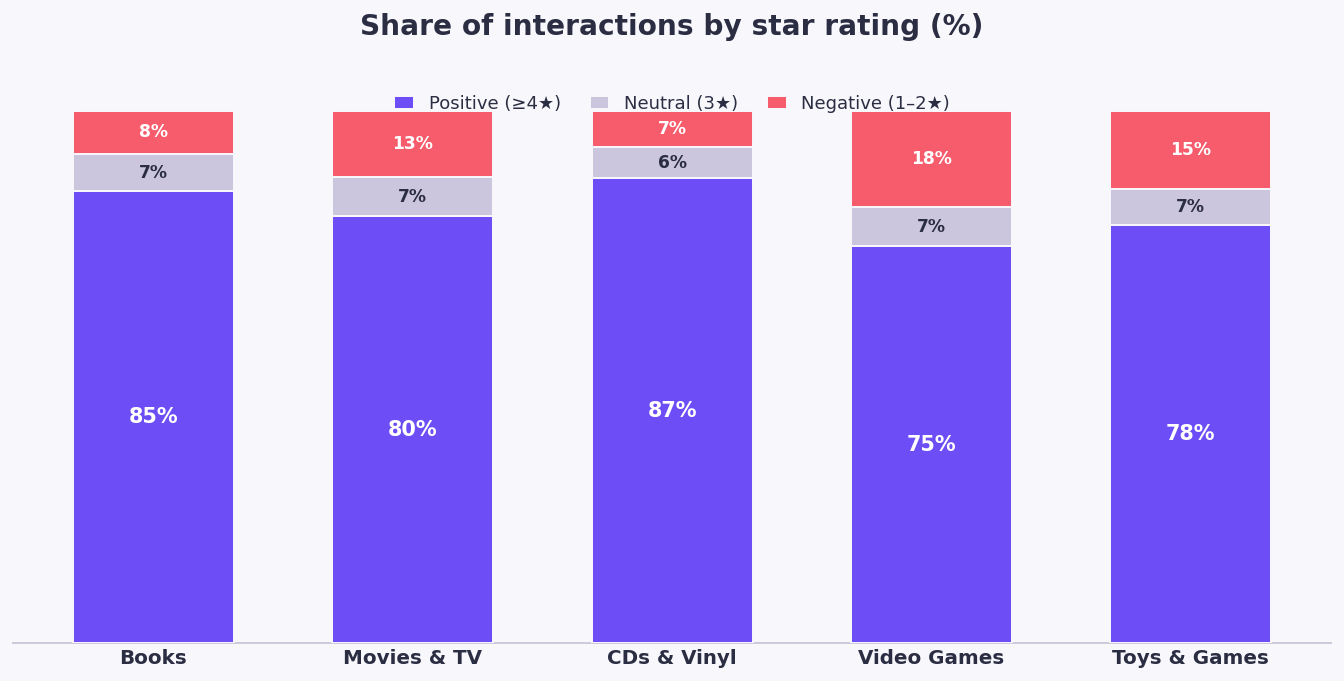

In [8]:
order = VERTICALS
tot = {v: sum(RATING_COUNTS[v]) for v in order}
pos = [(RATING_COUNTS[v][3] + RATING_COUNTS[v][4]) / tot[v] * 100 for v in order]   # >=4 star
neu = [ RATING_COUNTS[v][2]                          / tot[v] * 100 for v in order]   # 3 star
neg = [(RATING_COUNTS[v][0] + RATING_COUNTS[v][1]) / tot[v] * 100 for v in order]   # 1-2 star
fig, ax = plt.subplots(figsize=(10.5, 5.4))
x = np.arange(len(order)); w = 0.62
ax.bar(x, pos, w, color=PURPLE,  edgecolor=BG, linewidth=1.1, label='Positive (≥4★)', zorder=3)
ax.bar(x, neu, w, bottom=pos, color=NEUTRAL, edgecolor=BG, linewidth=1.1, label='Neutral (3★)', zorder=3)
ax.bar(x, neg, w, bottom=np.array(pos)+np.array(neu), color=CORAL, edgecolor=BG, linewidth=1.1,
       label='Negative (1–2★)', zorder=3)
for i in range(len(order)):
    ax.text(i, pos[i]/2, f'{pos[i]:.0f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=11.5)
    ax.text(i, pos[i]+neu[i]/2, f'{neu[i]:.0f}%', ha='center', va='center', color=INK, fontweight='bold', fontsize=9.5)
    ax.text(i, pos[i]+neu[i]+neg[i]/2, f'{neg[i]:.0f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=9.5)
ax.set_ylim(0, 100); ax.set_yticks([])
ax.set_xticks(x); ax.set_xticklabels([LBL[v] for v in order], fontweight='bold', color=INK)
ctitle(ax, 'Share of interactions by star rating (%)', size=15.5, pad=42)
style_bar_axis(ax, 'x')
brand_legend(ax, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.06), handlelength=1.1, columnspacing=1.6)
finish(fig)

### 2.4 · Activity over time

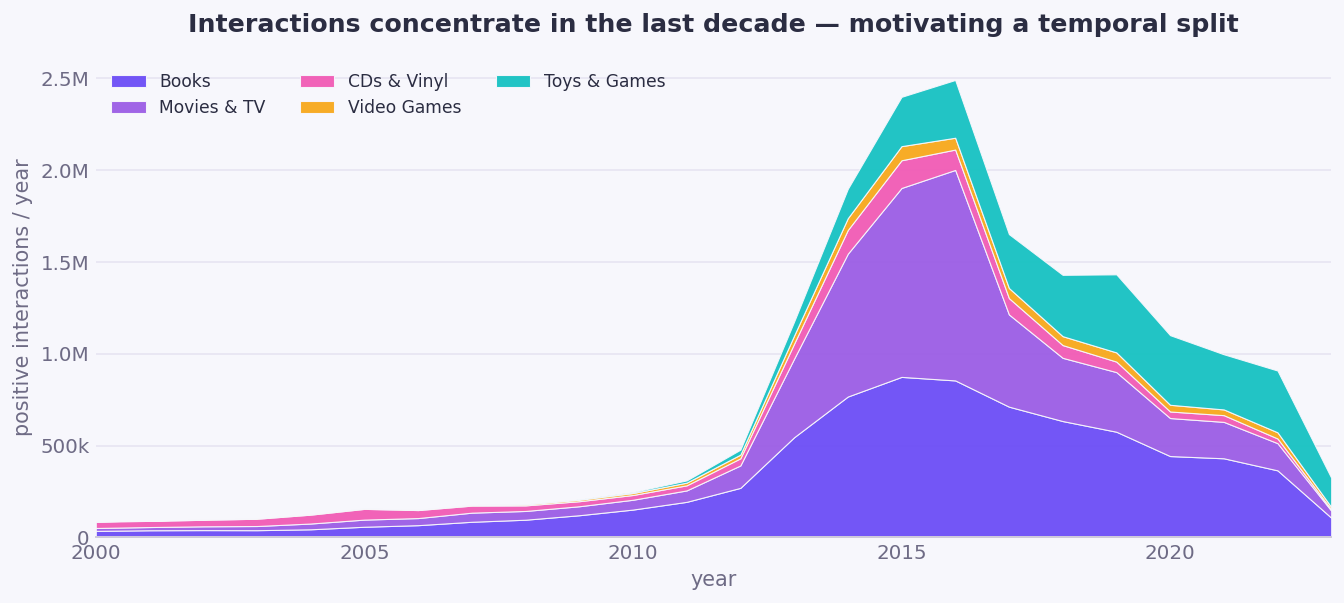

In [9]:
piv = (yearly[yearly['year'].between(2000, 2023)]
       .pivot_table(index='year', columns='vertical', values='count', fill_value=0)
       .reindex(columns=VERTICALS, fill_value=0))
fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.stackplot(piv.index.values, [piv[v].values for v in VERTICALS],
             labels=[LBL[v] for v in VERTICALS], colors=[VCOLORS[v] for v in VERTICALS],
             alpha=0.95, edgecolor=BG, linewidth=0.6)
ax.set_xlim(2000, 2023); ax.set_xlabel('year'); ax.set_ylabel('positive interactions / year')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: kfmt(v)))
ctitle(ax, 'Interactions concentrate in the last decade — motivating a temporal split', size=14)
style_bar_axis(ax, 'x'); soft_grid(ax, 'y')
brand_legend(ax, ncol=3, loc='upper left', fontsize=9.5)
finish(fig)

### 2.5 · The long tail & cold-start
*Left: how concentrated interactions are — a few items capture most of them. Right: how little history
most users have — the cold-start regime cross-domain transfer is built for.*

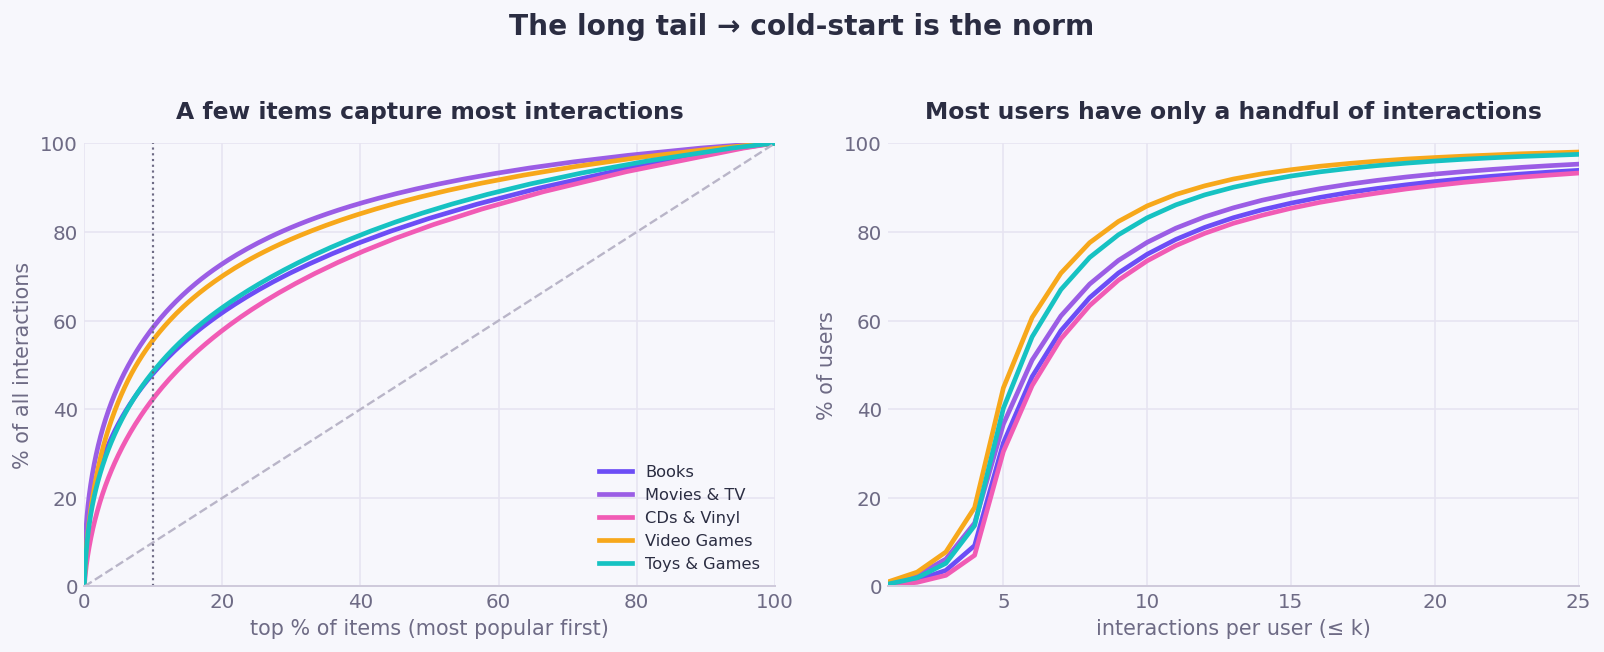

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.9))
# (a) Lorenz-style concentration curve
for v in VERTICALS:
    pop = np.sort(deg_item[deg_item['vertical'] == v]['pop'].values)[::-1]
    cum = np.cumsum(pop) / pop.sum() * 100
    xf = np.arange(1, len(pop)+1) / len(pop) * 100
    axes[0].plot(xf, cum, color=VCOLORS[v], lw=2.6, label=LBL[v])
axes[0].plot([0, 100], [0, 100], ls='--', color='#B9B5C8', lw=1.3)
axes[0].axvline(10, ls=':', color=INK_SOFT, lw=1.2)
axes[0].set_xlabel('top % of items (most popular first)'); axes[0].set_ylabel('% of all interactions')
axes[0].set_xlim(0, 100); axes[0].set_ylim(0, 100)
ctitle(axes[0], 'A few items capture most interactions', size=13)
style_line_axis(axes[0])
brand_legend(axes[0], fontsize=9, loc='lower right')
# (b) cold-start CDF
ks = np.arange(1, 26)
for v in VERTICALS:
    deg = deg_user[deg_user['vertical'] == v]['deg'].values
    axes[1].plot(ks, [(deg <= k).mean()*100 for k in ks], color=VCOLORS[v], lw=2.6, label=LBL[v])
axes[1].set_xlabel('interactions per user (≤ k)'); axes[1].set_ylabel('% of users')
axes[1].set_xlim(1, 25); axes[1].set_ylim(0, 100)
ctitle(axes[1], 'Most users have only a handful of interactions', size=13)
style_line_axis(axes[1])
fig.suptitle('The long tail → cold-start is the norm', color=INK, fontsize=15.5, fontweight='bold', y=1.02)
finish(fig)

### 2.6 · Catalog metadata coverage

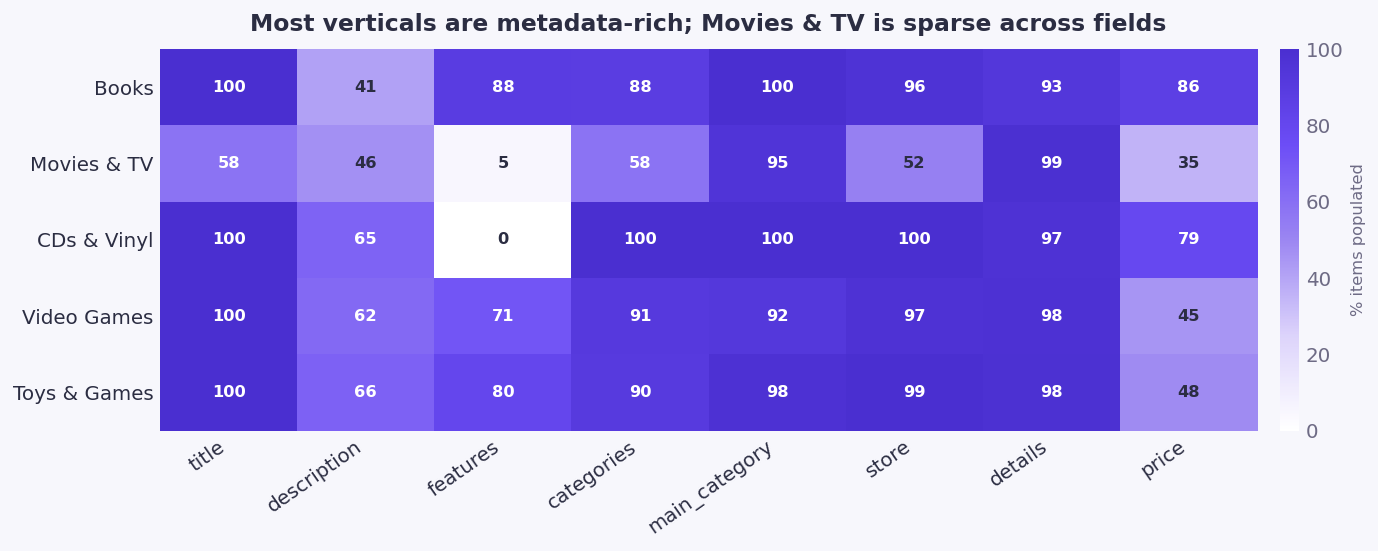

In [11]:
M = np.array([POP[v] for v in VERTICALS])
fig, ax = plt.subplots(figsize=(10.8, 4.4))
im = ax.imshow(M, cmap=PURPLES, vmin=0, vmax=100, aspect='auto')
ax.grid(False)
for s in ax.spines.values(): s.set_visible(False)
ax.set_xticks(range(len(POP_FIELDS))); ax.set_xticklabels(POP_FIELDS, rotation=35, ha='right', color=INK)
ax.set_yticks(range(len(VERTICALS))); ax.set_yticklabels([LBL[v] for v in VERTICALS], color=INK)
ax.tick_params(length=0)
for i in range(len(VERTICALS)):
    for j in range(len(POP_FIELDS)):
        ax.text(j, i, f'{M[i,j]:.0f}', ha='center', va='center', fontsize=9,
                color='white' if M[i,j] > 55 else INK, fontweight='bold')
ctitle(ax, 'Most verticals are metadata-rich; Movies & TV is sparse across fields', size=13, pad=10)
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cb.set_label('% items populated', fontsize=9, color=INK_SOFT)
cb.outline.set_visible(False); cb.ax.tick_params(length=0, colors=INK_SOFT)
finish(fig)

### 2.7 · Text embeddings & category vocabulary

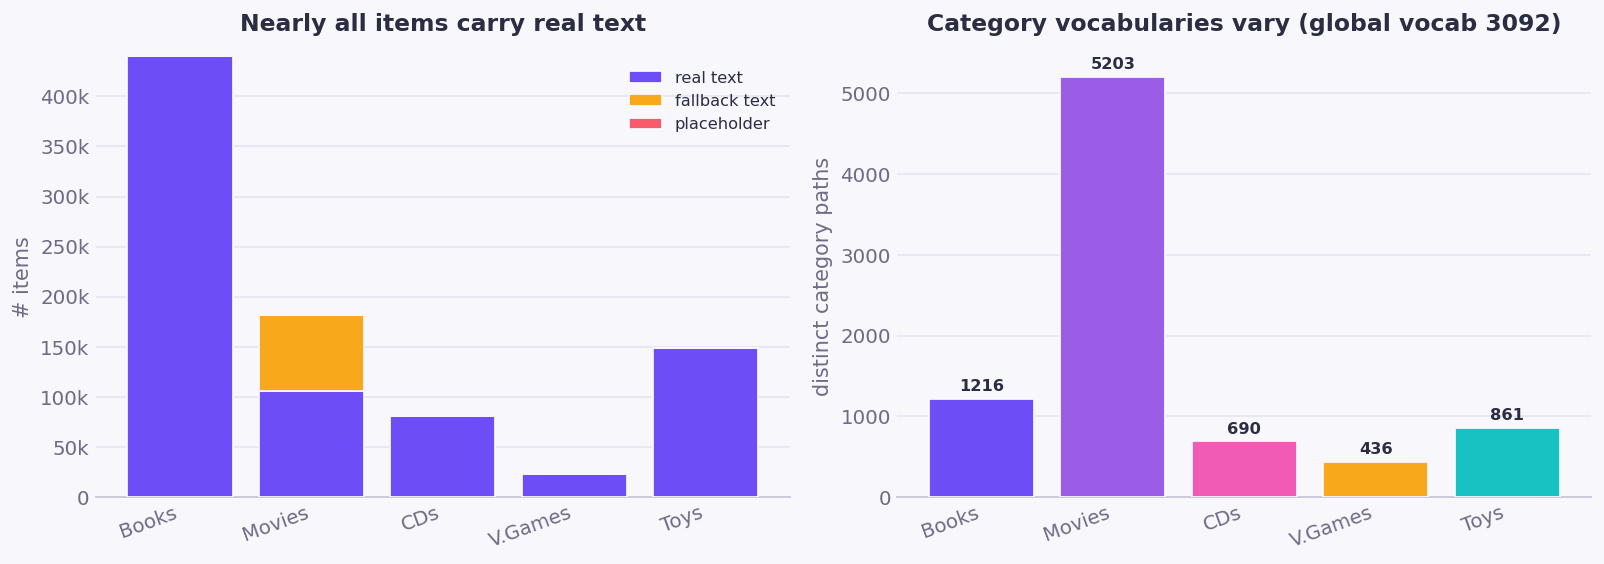

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
prim = [vstat(v)['clean']['text_primary'] for v in VERTICALS]
fall = [vstat(v)['clean']['text_fallback'] for v in VERTICALS]
ph   = [vstat(v)['clean']['text_none_placeholder'] for v in VERTICALS]
x = np.arange(len(VERTICALS))
axes[0].bar(x, prim, color=PURPLE, edgecolor=BG, label='real text', zorder=3)
axes[0].bar(x, fall, bottom=prim, color=ORANGE, edgecolor=BG, label='fallback text', zorder=3)
axes[0].bar(x, ph, bottom=np.array(prim)+np.array(fall), color=CORAL, edgecolor=BG, label='placeholder', zorder=3)
axes[0].set_xticks(x); axes[0].set_xticklabels([SHORT[v] for v in VERTICALS], rotation=20, ha='right')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: kfmt(v)))
axes[0].set_ylabel('# items'); ctitle(axes[0], 'Nearly all items carry real text', size=13)
style_bar_axis(axes[0], 'x'); soft_grid(axes[0], 'y')
brand_legend(axes[0], fontsize=9)
paths = [vstat(v)['construct']['category_distinct_paths'] for v in VERTICALS]
bars = axes[1].bar(x, paths, color=[VCOLORS[v] for v in VERTICALS], edgecolor=BG, zorder=3)
bar_annotated(axes[1], bars, paths, fmt='{:.0f}', fs=9)
axes[1].set_xticks(x); axes[1].set_xticklabels([SHORT[v] for v in VERTICALS], rotation=20, ha='right')
axes[1].set_ylabel('distinct category paths')
ctitle(axes[1], f'Category vocabularies vary (global vocab {DESC["category_vocab_size"]})', size=13)
style_bar_axis(axes[1], 'x'); soft_grid(axes[1], 'y')
finish(fig)

### 2.8 · Shared users across the 8 pairs

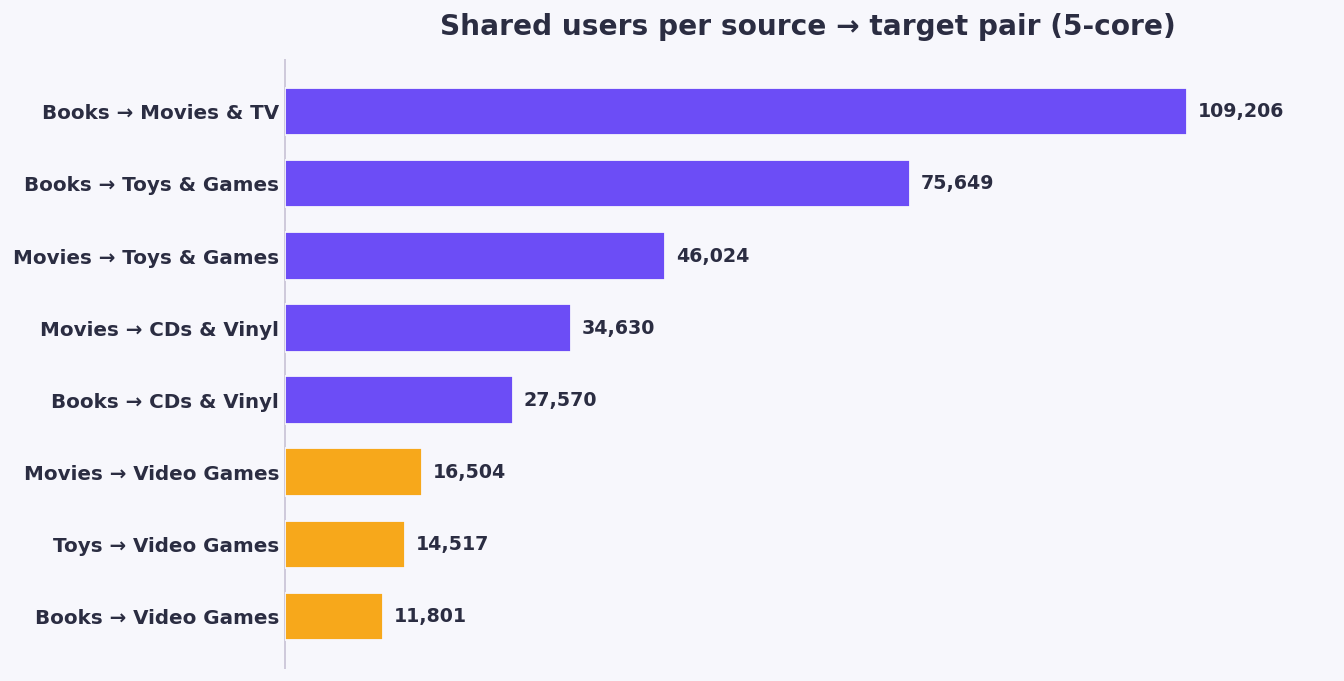

In [13]:
rows = [(s, t, pstat(s, t)['shared_users']) for s, t in PAIRS_FULL]
rows.sort(key=lambda r: r[2])                       # ascending -> largest ends on top
labels = [arr_lbl(s, t) for s, t, _ in rows]
shared = [r[2] for r in rows]
y = np.arange(len(rows))
colors = [ORANGE if t == 'Video_Games' else PURPLE for s, t, _ in rows]   # highlight below-cliff pairs
fig, ax = plt.subplots(figsize=(10.5, 5.4))
bars = ax.barh(y, shared, color=colors, edgecolor=BG, height=0.66, zorder=3)
for b, s in zip(bars, shared):
    ax.text(s + max(shared)*0.012, b.get_y()+b.get_height()/2, f'{s:,}',
            va='center', fontsize=10.5, color=INK, fontweight='bold')
ax.set_yticks(y); ax.set_yticklabels(labels, fontweight='bold', color=INK)
ax.set_xlim(0, max(shared)*1.16); ax.set_xticks([])
ctitle(ax, 'Shared users per source → target pair (5-core)', size=15.5)
style_bar_axis(ax, 'y')
finish(fig)

### 2.9 · Who is shared vs single-domain

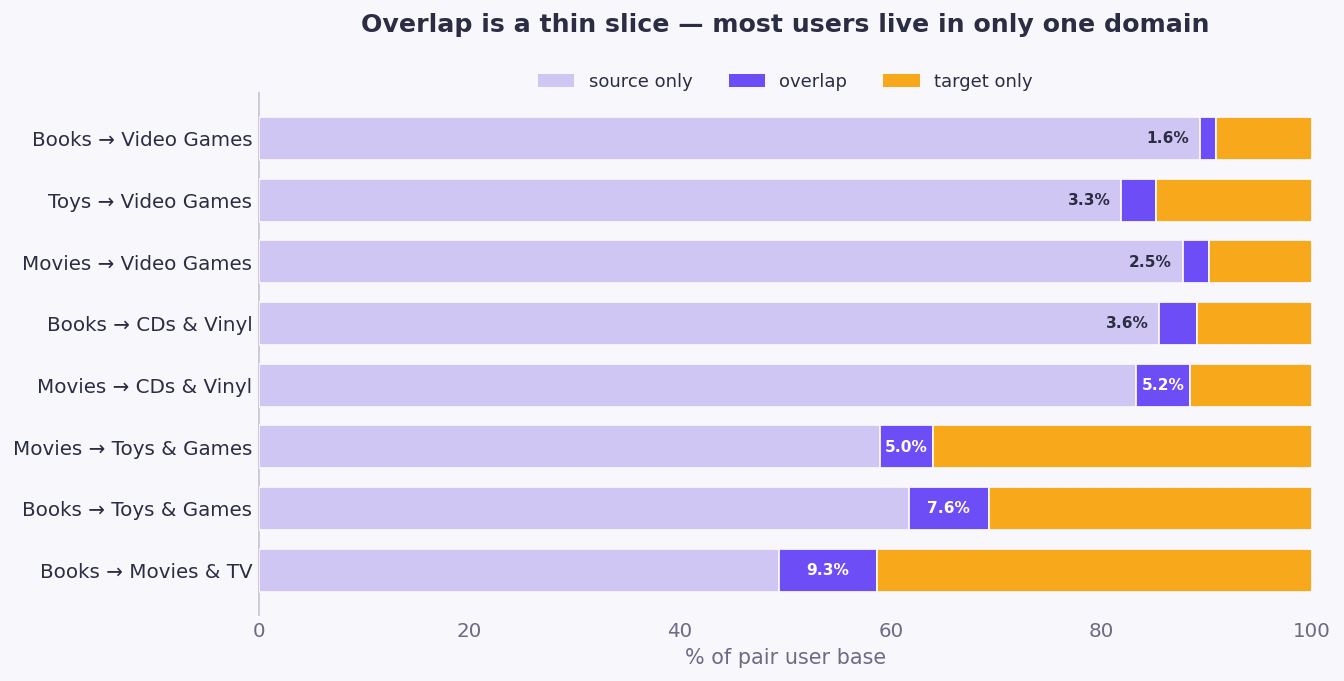

In [14]:
fig, ax = plt.subplots(figsize=(10.5, 5.4))
y = np.arange(len(PAIRS_FULL))
SRC_C, OVL_C, TGT_C = '#CFC6F4', PURPLE, ORANGE
for i, (s, t) in enumerate(PAIRS_FULL):
    p = pstat(s, t); tot = p['src_only_users'] + p['shared_users'] + p['tgt_only_users']
    segs = [p['src_only_users']/tot*100, p['shared_users']/tot*100, p['tgt_only_users']/tot*100]
    left = 0
    for w, c in zip(segs, [SRC_C, OVL_C, TGT_C]):
        ax.barh(i, w, left=left, color=c, edgecolor=BG, height=0.7, zorder=3); left += w
    ov0, ov1 = segs[0], segs[0]+segs[1]
    if segs[1] >= 4.5:                       # wide enough -> white label inside the slice
        ax.text((ov0+ov1)/2, i, f'{segs[1]:.1f}%', va='center', ha='center',
                fontsize=8.5, color='white', fontweight='bold')
    else:                                    # thin slice -> dark label in the light region to its left
        ax.text(ov0-1.0, i, f'{segs[1]:.1f}%', va='center', ha='right',
                fontsize=8.5, color=INK, fontweight='bold')
ax.set_yticks(y); ax.set_yticklabels([arr_lbl(s, t) for s, t in PAIRS_FULL], color=INK)
ax.set_xlim(0, 100); ax.set_xlabel('% of pair user base')
ctitle(ax, 'Overlap is a thin slice — most users live in only one domain', size=14, pad=34)
style_bar_axis(ax, 'y')
brand_legend(ax, handles=[Patch(facecolor=SRC_C, label='source only'),
                          Patch(facecolor=OVL_C, label='overlap'),
                          Patch(facecolor=TGT_C, label='target only')],
             ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.07))
finish(fig)

## 3 · Baselines
Four reference points per pair, in increasing sophistication:
**Random**, **MostPop** (raw popularity, the deployed fallback), **target-MF** (the average target user
— a popularity prior in embedding space, *uses no source info*), and **content-transfer** (training-free
cosine between the source liked-item text and target item text — a simple content CDR).

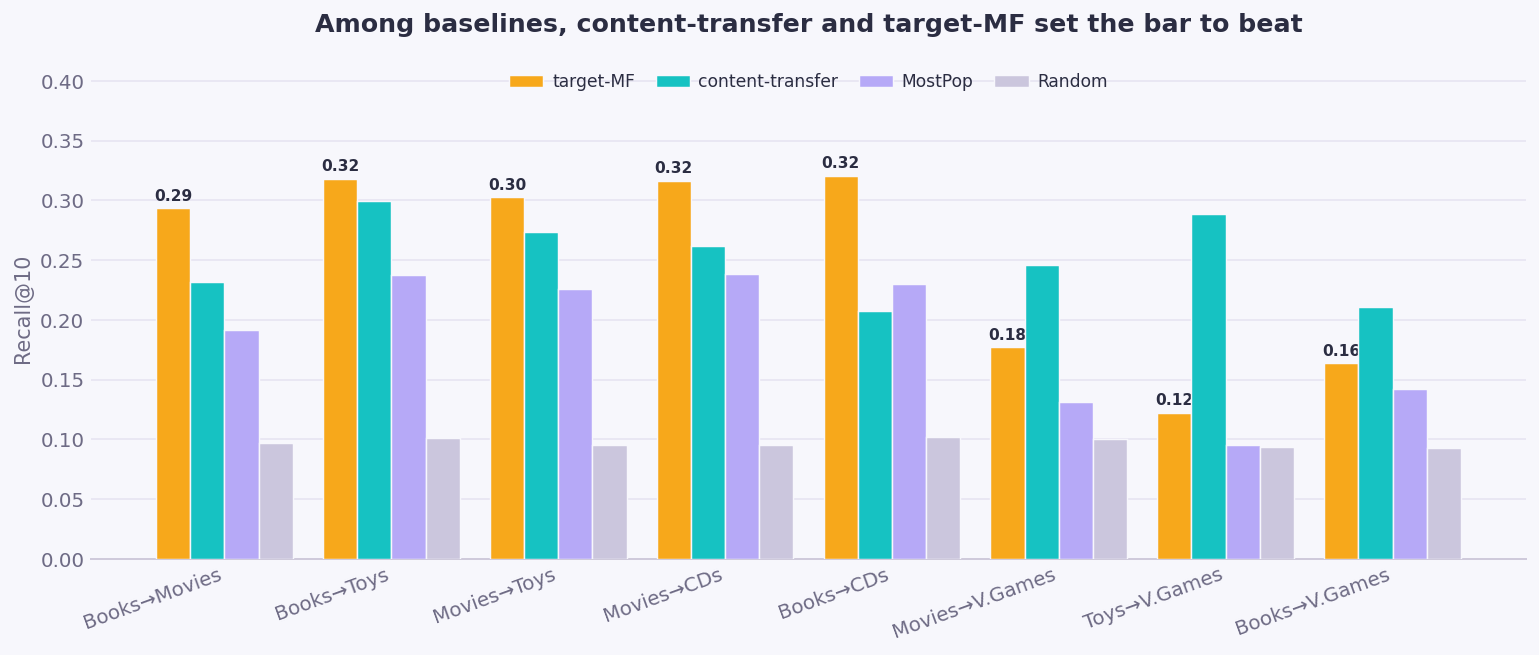

In [15]:
fig, ax = plt.subplots(figsize=(12, 5.2))
ents = entries_for('improve_lin', PAIRS_FULL)
grouped_models(ax, PAIRS_FULL, ents, BASELINES, 'Recall@10',
               'Among baselines, content-transfer and target-MF set the bar to beat',
               annotate='baseline_target_mf')
ax.set_ylim(0, 0.42)
finish(fig)

## 4 · Our solution — EMCDR
Train a recommender per vertical, then learn a mapping `f` from a shared user's **source** embedding to
their **target** embedding. For a cold target user we map their source vector and score it against the
target catalog. Items are grounded in content (MiniLM text + categories + popularity).

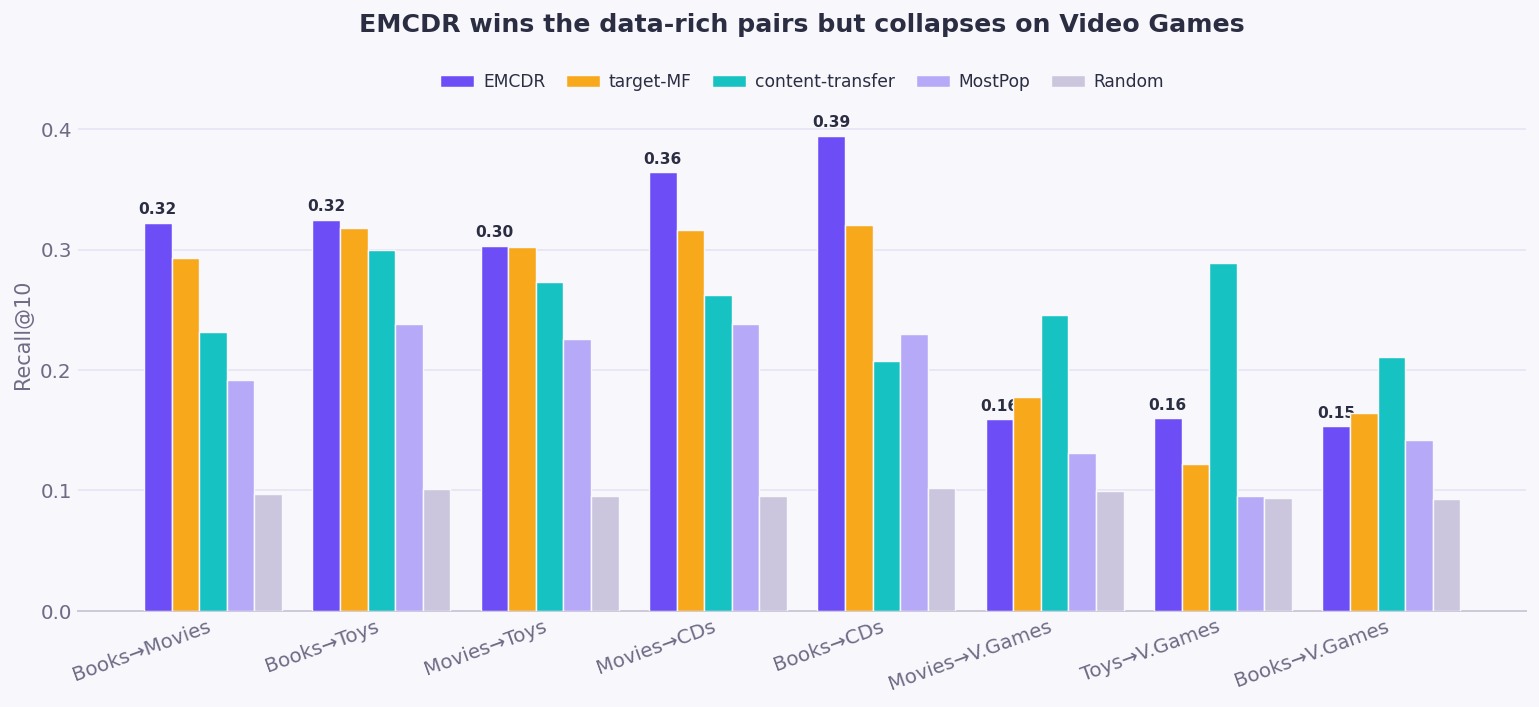

In [16]:
# EMCDR vs all baselines (regularized-linear mapping)
fig, ax = plt.subplots(figsize=(12, 5.6))
ents = entries_for('improve_lin', PAIRS_FULL)
grouped_models(ax, PAIRS_FULL, ents, ALLMODELS, 'Recall@10',
               'EMCDR wins the data-rich pairs but collapses on Video Games')
ax.set_ylim(0, 0.46)
finish(fig)

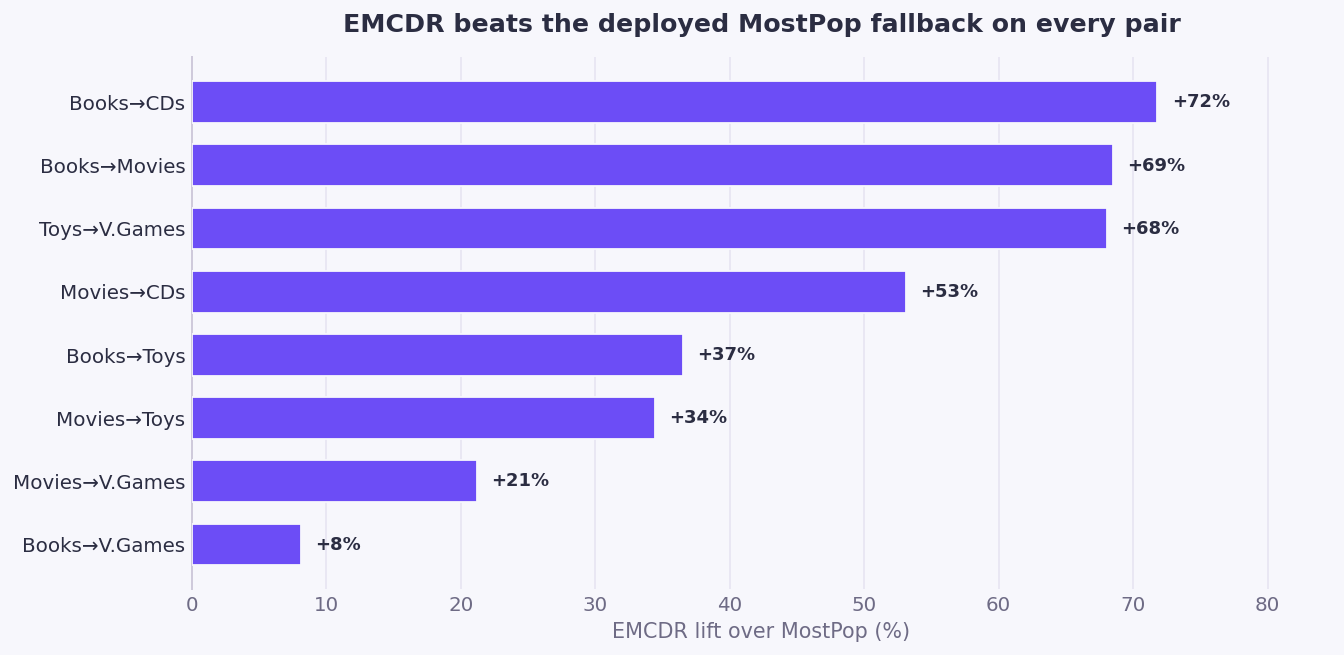

In [17]:
# lift over MostPop — EMCDR clears the deployed fallback on every pair
fig, ax = plt.subplots(figsize=(10.5, 5.2))
ents = entries_for('improve_lin', PAIRS_FULL)
lift = [(mval(e, 'emcdr') - mval(e, 'baseline_mostpop')) / mval(e, 'baseline_mostpop') * 100 for e in ents]
order = np.argsort(lift)
y = np.arange(len(ents))
ax.barh(y, np.array(lift)[order], color=PURPLE, edgecolor=BG, height=0.66, zorder=3)
ax.set_yticks(y); ax.set_yticklabels([plabel(*PAIRS_FULL[i]) for i in order], color=INK)
for i, val in enumerate(np.array(lift)[order]):
    ax.text(val + max(lift)*0.015, i, f'+{val:.0f}%', va='center', fontsize=10, color=INK, fontweight='bold')
ax.set_xlim(0, max(lift)*1.18); ax.set_xlabel('EMCDR lift over MostPop (%)')
ctitle(ax, 'EMCDR beats the deployed MostPop fallback on every pair', size=14)
style_bar_axis(ax, 'y'); soft_grid(ax, 'x')
finish(fig)

## 5 · Improvements & the honest boundary
Three targeted fixes: **A1** a regularized *linear* mapping (rich pairs), **B1** a content-grounded
target item tower, and **B2** a denser 3-core Video-Games target (~2× overlap).

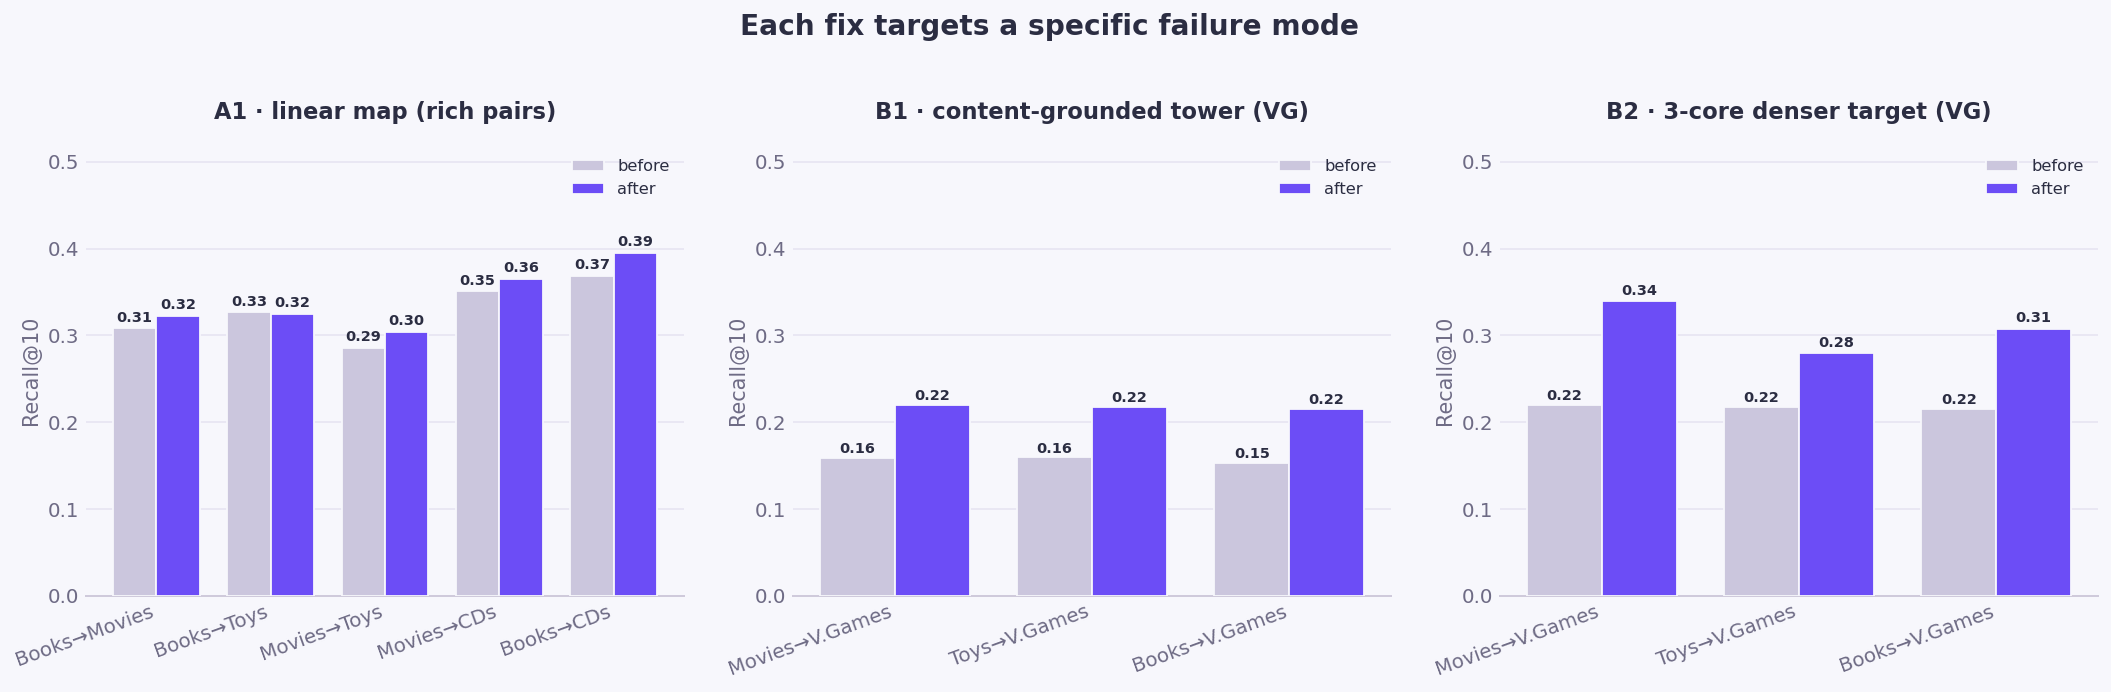

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2))
def beforeafter(ax, title, items):
    x = np.arange(len(items)); w = 0.38
    bef = [b for _, b, _ in items]; aft = [a for _, _, a in items]
    b1 = ax.bar(x - w/2, bef, w, label='before', color=NEUTRAL, edgecolor=BG, zorder=3)
    b2 = ax.bar(x + w/2, aft, w, label='after', color=PURPLE, edgecolor=BG, zorder=3)
    bar_annotated(ax, b1, bef, fmt='{:.2f}', fs=8); bar_annotated(ax, b2, aft, fmt='{:.2f}', fs=8)
    ax.set_xticks(x); ax.set_xticklabels([n for n, _, _ in items], rotation=20, ha='right')
    ax.set_ylabel('Recall@10'); ax.set_ylim(0, 0.52)
    ctitle(ax, title, size=12.5)
    style_bar_axis(ax, 'x'); soft_grid(ax, 'y')
    brand_legend(ax, loc='upper right', fontsize=9)

RICH = PAIRS_FULL[:5]
a1 = [(plabel(s, t), mval(entry('full', s, t), 'emcdr'), mval(entry('improve_lin', s, t), 'emcdr')) for s, t in RICH]
beforeafter(axes[0], 'A1 · linear map (rich pairs)', a1)

VG = [('Movies_and_TV','Video_Games'), ('Toys_and_Games','Video_Games'), ('Books','Video_Games')]
b1 = [(plabel(s, t), mval(entry('improve_lin', s, t), 'emcdr'), mval(entry('b1', s, t), 'emcdr')) for s, t in VG]
beforeafter(axes[1], 'B1 · content-grounded tower (VG)', b1)

b2 = [(plabel(s, 'Video_Games'),
       mval(entry('b1', s, 'Video_Games'), 'emcdr'),
       mval(entry('b1_3core', s, 'Video_Games_3core'), 'emcdr')) for s in ['Movies_and_TV', 'Toys_and_Games', 'Books']]
beforeafter(axes[2], 'B2 · 3-core denser target (VG)', b2)
fig.suptitle('Each fix targets a specific failure mode', color=INK, fontsize=15.5, fontweight='bold', y=1.02)
finish(fig)

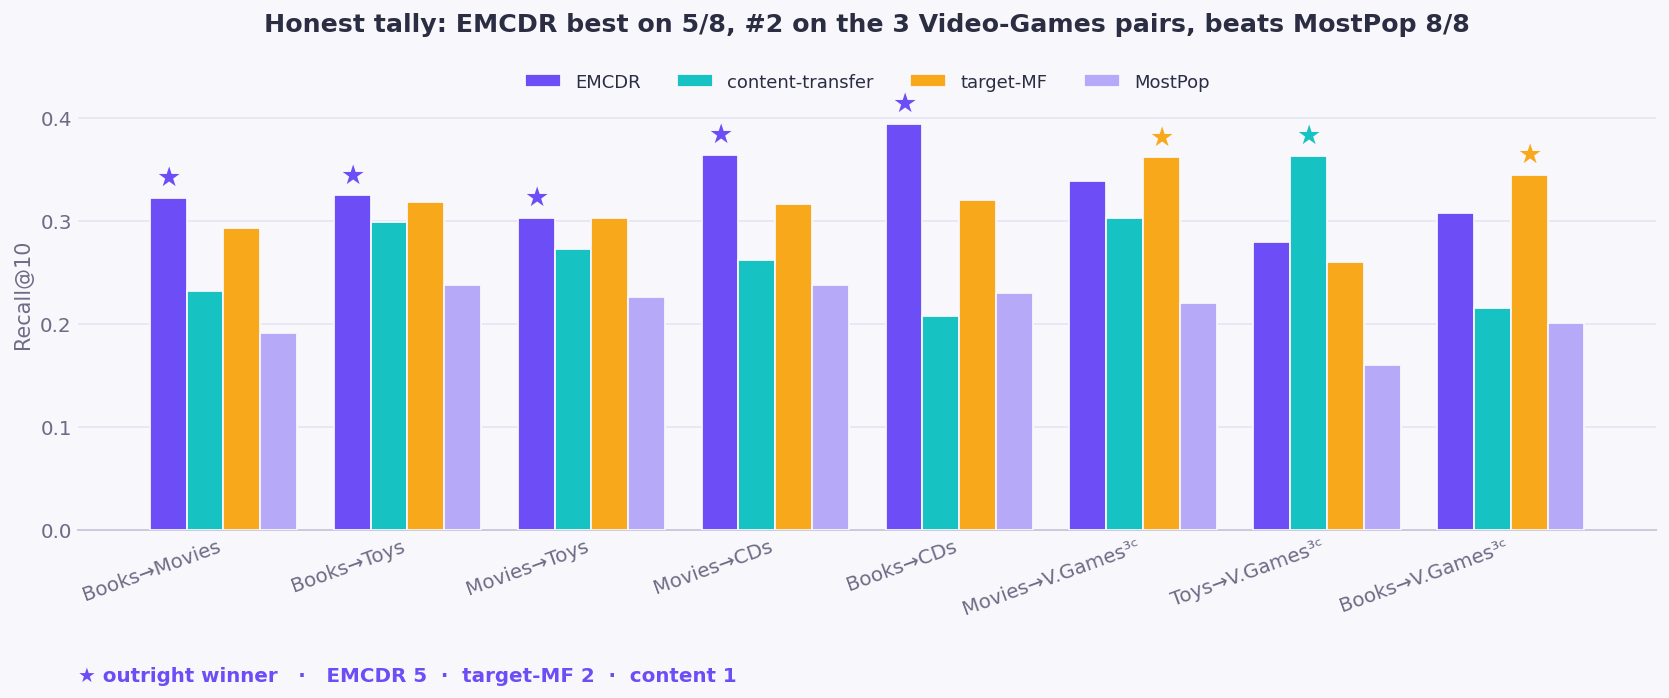

In [19]:
# honest final tally — best deployed config per pair
fig, ax = plt.subplots(figsize=(13, 5.8))
cols = ['emcdr', 'baseline_feature_transfer', 'baseline_target_mf', 'baseline_mostpop']
x = np.arange(len(DEPLOYED)); w = 0.2
tally = {}
for k, m in enumerate(cols):
    vals = [mval(entry(tag, s, t), m) for s, t, tag in DEPLOYED]
    ax.bar(x + (k-1.5)*w, vals, w, label=MODEL_LBL[m], color=MODEL_COLORS[m], edgecolor=BG, zorder=3)
for i, (s, t, tag) in enumerate(DEPLOYED):
    e = entry(tag, s, t); win = winner_of(e); tally[win] = tally.get(win, 0) + 1
    kw = cols.index(win) if win in cols else 1.5                # align star to the winning bar
    ax.text(x[i] + (kw-1.5)*w, mval(e, win) + 0.012, '★', ha='center', fontsize=15,
            color=MODEL_COLORS[win])
ax.set_xticks(x); ax.set_xticklabels([plabel(s, t) for s, t, _ in DEPLOYED], rotation=20, ha='right')
ax.set_ylabel('Recall@10'); ax.set_ylim(0, 0.46)
ctitle(ax, 'Honest tally: EMCDR best on 5/8, #2 on the 3 Video-Games pairs, beats MostPop 8/8', size=14)
style_bar_axis(ax, 'x'); soft_grid(ax, 'y')
brand_legend(ax, ncol=4, loc='upper center', bbox_to_anchor=(0.5, 1.0))
txt = (f"★ outright winner   ·   EMCDR {tally.get('emcdr',0)}  ·  "
       f"target-MF {tally.get('baseline_target_mf',0)}  ·  content {tally.get('baseline_feature_transfer',0)}")
ax.text(0.0, -0.32, txt, transform=ax.transAxes, fontsize=11, color=PURPLE, fontweight='bold')
finish(fig)

## Takeaways
- **Cross-domain transfer pays off where the theory says it should** — high overlap *and* a content-rich
  target: EMCDR is the outright best model on the 5 rich pairs and beats the deployed MostPop fallback 8/8.
- **On sparse targets a popularity prior is hard to beat** — on the 3 Video-Games pairs EMCDR is a close #2;
  target-MF / content win. Doubling the overlap (3-core) didn't change the verdict → it's the sparse target,
  not the sample size.
- **The winner is predictable a priori from overlap size** → deploy EMCDR above the cliff, fall back to the
  popularity prior below it.

In [20]:
# ── verification: tallies match the docs ──
full_wins     = [winner_of(entry('full', s, t))        for s, t in PAIRS_FULL]
improved_wins = [winner_of(entry('improve_lin', s, t)) for s, t in PAIRS_FULL]
dep_wins      = [winner_of(entry(tag, s, t))           for s, t, tag in DEPLOYED]
from collections import Counter
print('base-run EMCDR outright wins     :', full_wins.count('emcdr'),     '/ 8   (expect 4)')
print('improved (linear-map) EMCDR wins :', improved_wins.count('emcdr'), '/ 8   (expect 5)')
print('deployed winners                 :', dict(Counter(dep_wins)))
print('EMCDR beats MostPop on           :',
      sum(mval(entry(tag, s, t), 'emcdr') > mval(entry(tag, s, t), 'baseline_mostpop')
          for s, t, tag in DEPLOYED), '/ 8')
assert full_wins.count('emcdr') == 4
assert improved_wins.count('emcdr') == 5
assert Counter(dep_wins) == {'emcdr': 5, 'baseline_target_mf': 2, 'baseline_feature_transfer': 1}
print('OK — numbers match RESULTS.md / IMPROVEMENTS.md')

base-run EMCDR outright wins     : 4 / 8   (expect 4)
improved (linear-map) EMCDR wins : 5 / 8   (expect 5)
deployed winners                 : {'emcdr': 5, 'baseline_target_mf': 2, 'baseline_feature_transfer': 1}
EMCDR beats MostPop on           : 8 / 8
OK — numbers match RESULTS.md / IMPROVEMENTS.md
